# Casino Night

**Programming Design Principles (5N2927) -- Skills Demo 2a, 15%**
**Maths for IT (5N18396) -- Assignment 1a, 12%**

Dundrum College of Further Education | Dublin and Dun Laoghaire ETB

---

Welcome to Casino Night. You are going to build a card game simulator, use it to explore probability, and then analyse the results with statistics. The mathematics and the programming are the same activity: every probability formula becomes a function, every statistical measure becomes a test of your simulation.

## Assessment Criteria

| Criterion | PDP Marks | MIT Marks |
|---|---|---|
| Pseudocode and algorithm design | 4 | -- |
| Working code with functions and testing | 8 | -- |
| Correct application of counting/probability | -- | 6 |
| Accurate calculations with proper notation | -- | 3 |
| Coherent format and logical progression | -- | 3 |

---

## The Deck

Run the cell below to set up our card deck and some helper functions.

In [1]:
# === PROVIDED: Card deck and helpers ===
import random
import matplotlib.pyplot as plt

RANKS = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]
SUITS = ["Hearts", "Diamonds", "Clubs", "Spades"]

def make_deck():
    """Create a standard 52-card deck as a list of (rank, suit) tuples."""
    return [(rank, suit) for suit in SUITS for rank in RANKS]

def deal_hand(deck, n=5):
    """Shuffle the deck and deal n cards."""
    shuffled = deck.copy()
    random.shuffle(shuffled)
    return shuffled[:n]

def is_face_card(card):
    """Check if a card is a face card (J, Q, K)."""
    return card[0] in ["J", "Q", "K"]

def card_value(card):
    """Numeric value: 2-10 are face value, J=11, Q=12, K=13, A=14."""
    rank = card[0]
    if rank == "A": return 14
    if rank == "K": return 13
    if rank == "Q": return 12
    if rank == "J": return 11
    return int(rank)

def plot_distribution(labels, observed, expected=None, title=""):
    """Plot observed frequencies, optionally with expected overlay."""
    fig, ax = plt.subplots(figsize=(8, 5))
    x = range(len(labels))
    ax.bar(x, observed, color='#4e79a7', edgecolor='black', alpha=0.7, label='Observed')
    if expected:
        ax.plot(x, expected, 'ro-', linewidth=2, markersize=6, label='Expected')
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=45 if len(labels) > 8 else 0)
    ax.set_ylabel('Frequency')
    ax.set_title(title)
    if expected:
        ax.legend()
    plt.tight_layout()
    plt.show()

deck = make_deck()
print(f"Deck has {len(deck)} cards.")
print("Sample hand:", deal_hand(deck))

Deck has 52 cards.
Sample hand: [('2', 'Spades'), ('3', 'Diamonds'), ('2', 'Clubs'), ('J', 'Spades'), ('10', 'Diamonds')]


---

### Exercise 1: Counting and Probability

First, let's build our counting tools and use them to calculate card probabilities *exactly*.

Write three functions: `factorial(n)`, `permutations(n, r)`, and `combinations(n, r)`. Then use them to answer the questions below.

In [2]:
# Pseudocode:
# factorial(n): multiply together every integer from 1 to n (0! is 1 by definition)
# permutations(n, r): factorial(n) / factorial(n - r)
# combinations(n, r): factorial(n) / (factorial(r) * factorial(n - r))


In [3]:
def factorial(n):
    """Compute n! (n factorial)."""
    if n == 0:
        return 1
    result = 1
    for i in range(1, n + 1):
        result *= i
    return result

def permutations(n, r):
    """Number of ways to arrange r items from n (order matters)."""
    return factorial(n) // factorial(n - r)

def combinations(n, r):
    """Number of ways to choose r items from n (order doesn't matter)."""
    return factorial(n) // (factorial(r) * factorial(n - r))


In [4]:
# Test your functions
# factorial(5) should be 120
# combinations(52, 5) should be 2598960
# permutations(52, 5) should be 311875200
print(factorial(5))
print(combinations(52, 5))
print(permutations(52, 5))


120
2598960
311875200


**Now use them.** Calculate the probability of each event when dealing a 5-card hand from a 52-card deck. Show your reasoning alongside the code.

Remember: $P(\text{event}) = \frac{\text{number of favourable hands}}{\text{total possible hands}}$

In [5]:
total_hands = combinations(52, 5)
print("Total possible 5-card hands:", total_hands)

# 1. Probability all 5 cards are hearts
#    (13 hearts in the deck, choose 5)
hearts_hands = combinations(13, 5)
p_all_hearts = hearts_hands / total_hands
print("P(all hearts):", p_all_hearts)

# 2. Probability of getting exactly one ace
#    (choose 1 ace from 4, choose 4 non-aces from 48)
one_ace_hands = combinations(4, 1) * combinations(48, 4)
p_one_ace = one_ace_hands / total_hands
print("P(exactly one ace):", p_one_ace)

# 3. Probability of getting no face cards
#    (40 non-face cards in the deck, choose 5)
no_face_hands = combinations(40, 5)
p_no_face = no_face_hands / total_hands
print("P(no face cards):", p_no_face)


Total possible 5-card hands: 2598960
P(all hearts): 0.0004951980792316927
P(exactly one ace): 0.2994736356080894
P(no face cards): 0.2531812725090036


---

### Exercise 2: Simulation

Now let's check our calculations by dealing thousands of hands and counting how often each event occurs.

In [6]:
# Pseudocode:
# Build a deck. For each of num_deals trials:
#     shuffle and deal hand_size cards
#     if every card is a heart, add one to the all-hearts counter
#     count the aces in the hand -- if there is exactly one, add one to that counter
#     if none of the cards are face cards, add one to that counter
# Return the three counters in a dictionary


In [7]:
def simulate_deals(num_deals, hand_size=5):
    """
    Deal many hands and count:
    - how many are all hearts
    - how many have exactly one ace
    - how many have no face cards

    Returns: dictionary of counts
    """
    counts = {"all_hearts": 0, "exactly_one_ace": 0, "no_face_cards": 0}
    for _ in range(num_deals):
        hand = deal_hand(deck, hand_size)
        if all(card[1] == "Hearts" for card in hand):
            counts["all_hearts"] += 1
        num_aces = sum(1 for card in hand if card[0] == "A")
        if num_aces == 1:
            counts["exactly_one_ace"] += 1
        if not any(is_face_card(card) for card in hand):
            counts["no_face_cards"] += 1
    return counts


In [8]:
# Run the simulation
results = simulate_deals(100000)

# Compare simulated proportions to calculated probabilities
# (your calculated values from Exercise 1)
print("Simulated P(all hearts):", results["all_hearts"] / 100000, "vs calculated", p_all_hearts)
print("Simulated P(exactly one ace):", results["exactly_one_ace"] / 100000, "vs calculated", p_one_ace)
print("Simulated P(no face cards):", results["no_face_cards"] / 100000, "vs calculated", p_no_face)


Simulated P(all hearts): 0.00059 vs calculated 0.0004951980792316927
Simulated P(exactly one ace): 0.29968 vs calculated 0.2994736356080894
Simulated P(no face cards): 0.25405 vs calculated 0.2531812725090036


Do your simulated proportions match your calculated probabilities? If there is a small difference, that is expected -- simulation gives approximations that get closer with more trials.

---

### Exercise 3: Statistics of Card Values

Deal 1000 hands of 5 cards each. For each hand, compute the sum of the card values. Then analyse the distribution of these sums.

Write functions for `mean(data)`, `median(data)`, and `std_dev(data)`, then apply them.

In [9]:
# Pseudocode:
# mean(data): sum the values, divide by how many there are
# median(data): sort the values; if there is an odd count take the middle
#     one, if even take the average of the two middle ones
# std_dev(data): find the mean, then the average squared distance from the
#     mean, then take the square root of that


In [10]:
def mean(data):
    """Arithmetic mean of a list of numbers."""
    return sum(data) / len(data)

def median(data):
    """Median of a list of numbers."""
    ordered = sorted(data)
    n = len(ordered)
    mid = n // 2
    if n % 2 == 0:
        return (ordered[mid - 1] + ordered[mid]) / 2
    return ordered[mid]

def std_dev(data):
    """Population standard deviation."""
    m = mean(data)
    variance = sum((x - m) ** 2 for x in data) / len(data)
    return variance ** 0.5


In [11]:
# Deal 1000 hands, compute the sum of card values in each
hand_sums = []
for _ in range(1000):
    hand = deal_hand(deck)
    total = sum(card_value(c) for c in hand)
    hand_sums.append(total)

print("Mean hand value:", mean(hand_sums))
print("Median hand value:", median(hand_sums))
print("Standard deviation:", round(std_dev(hand_sums), 2))
print("Min:", min(hand_sums), "Max:", max(hand_sums))

Mean hand value: 40.31
Median hand value: 40.0
Standard deviation: 7.86
Min: 19 Max: 63


**Visualise it:** Create a histogram of the hand value sums. What shape does the distribution have?

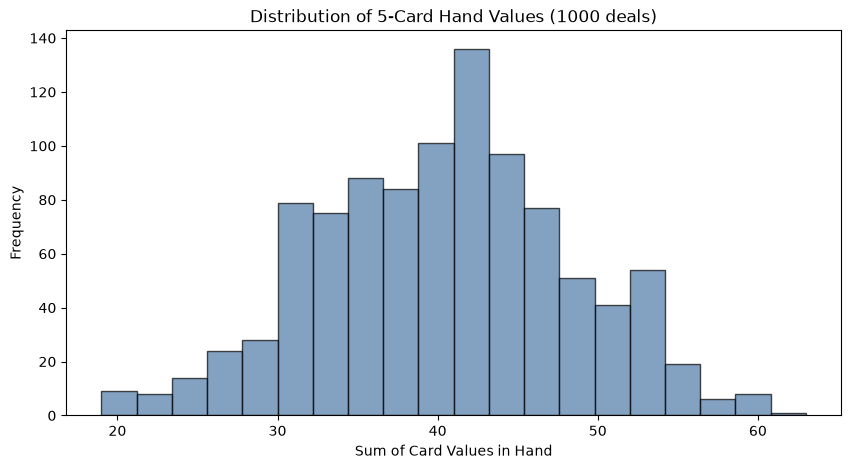

In [12]:
# Your histogram here
plt.figure(figsize=(10, 5))
plt.hist(hand_sums, bins=20, color='#4e79a7', edgecolor='black', alpha=0.7)
plt.xlabel('Sum of Card Values in Hand')
plt.ylabel('Frequency')
plt.title('Distribution of 5-Card Hand Values (1000 deals)')
plt.show()

# What shape is this? Write your observation:
# The distribution looks roughly bell-shaped, centred near the average
# hand total. That is what we would expect: most hands land close to the
# mean, and very high or very low totals need an unusual run of cards, so
# they turn up less often.


---

### Reflection

Write a few sentences about what you learned. Did the simulation results surprise you? What does the histogram shape tell you about card games?

